# Feature Scaling with k-Nearest Neighbors

k-NN is a distance-based algorithm, making it sensitive to the scale of the features. If one feature has a much larger range than another, it will dominate the distance calculation.

In this notebook, we'll:
1. Generate synthetic data where features have different scales.
2. Observe how unscaled features lead to non-sensical nearest neighbors.
3. Implement standardization to put features on a similar scale.
4. Visualize how feature scaling improves the decision boundary.

Let's start with a synthetic dataset containing age and income data, and create a rule that determines whether or not they own a  massage chair. Only young with disposable income will get one but, as age increases, so does the need for the sweet relief of mechanized rollers.

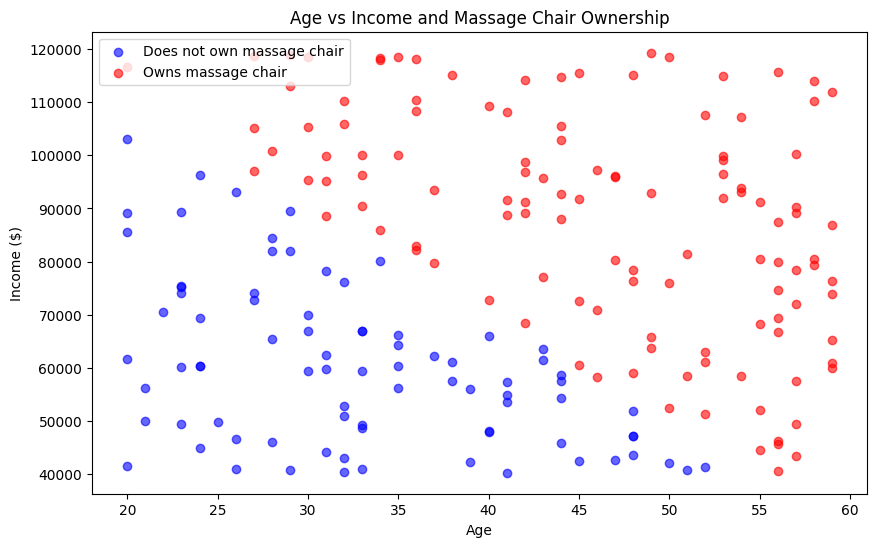

((200, 2), (200,))

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(2025)
age = np.random.randint(20, 60, size=200)
income = np.random.randint(40_000, 120_000, size=200) # typically lognormally distributed and correlated with age but simplified here
# Vertical split: young with high income or old with low income more likely to own massage chair, with linear boundary
owns_massage_chair = (income + (2000 * age) - 150_000) > 0

x_train = np.column_stack((age, income))
y_train = owns_massage_chair.astype(int)

# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(age[~owns_massage_chair], income[~owns_massage_chair], color='blue', label='Does not own massage chair', alpha=0.6)
plt.scatter(age[owns_massage_chair], income[owns_massage_chair], color='red', label='Owns massage chair', alpha=0.6)
plt.title('Age vs Income and Massage Chair Ownership')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()
plt.show()

x_train.shape, y_train.shape


We'll use the same k-NN classification logic as before: calculating distances, sorting, and taking a majority vote.

In [6]:
def knn_classify(x_train, y_train, x_query, k):
    y_query = []
    for x in x_query:
        # 1. Distance
        distance = np.linalg.norm(x_train - x, axis=1)

        # 2. Sort
        sorted_indices = np.argsort(distance)

        # 3. Select
        k_indices = sorted_indices[:k]

        # 4. Vote
        k_nearest_labels = y_train[k_indices]
        counts = np.bincount(k_nearest_labels)
        predicted_label = np.argmax(counts)

        y_query.append(predicted_label)
    return np.array(y_query), sorted_indices[:k]

Now, let's pick a query point. We'll choose a 20-year-old with an income of $99,900. Logically, this person is "close" to the boundary where people own massage chairs, but let's see who their numerical "nearest neighbors" are.

Predicted label for query point Age=20 Income=99,900: Owns Massage Chair


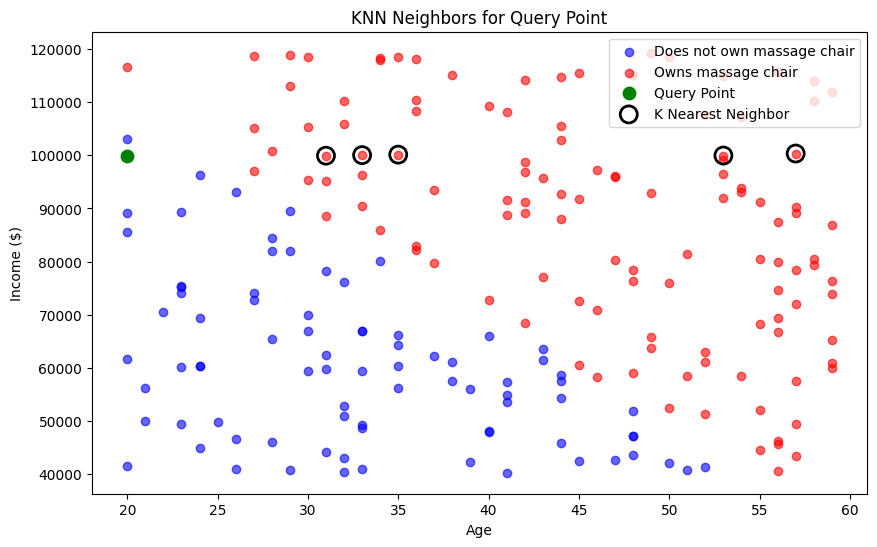

In [ ]:
# Query point logically close to boundary but numerically far in income
x_query = np.array([[20, 99_900]])

# Classify query point
k = 5
y_query, sorted_indices = knn_classify(x_train, y_train, x_query, k)
print(f'Predicted label for query point Age={x_query[0][0]} Income={x_query[0][1]:,.0f}: {"Owns Massage Chair" if y_query[0] == 1 else "Does Not Own Massage Chair"}')

# Visualize neighbors
plt.figure(figsize=(10, 6))
plt.scatter(age[~owns_massage_chair], income[~owns_massage_chair], color='blue', label='Does not own massage chair', alpha=0.6)
plt.scatter(age[owns_massage_chair], income[owns_massage_chair], color='red', label='Owns massage chair', alpha=0.6)
plt.scatter(x_query[0][0], x_query[0][1], color='green', label='Query Point', s=80)
for i in range(k):
    idx = sorted_indices[i]
    plt.scatter(x_train[idx][0], x_train[idx][1], facecolors='none', edgecolors='black', s=150, linewidths=2, label=f'K Nearest Neighbor' if i == 0 else "")
plt.title('KNN Neighbors for Query Point')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend(loc='upper right')
plt.show()

It's immediately clear that these "nearest neighbors" don't make sense. When we plot the decision boundary, we see alternating bands that change only with income. The distance in the income dimension is so large that changes in age are ignored.

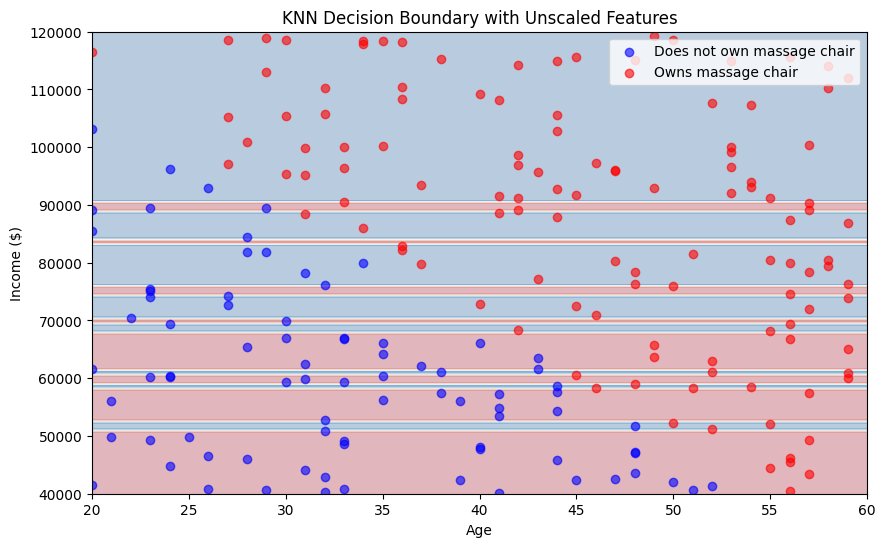

In [ ]:
# Plot decision boundary with scaled features
age_range = np.linspace(20, 60, 100)
income_range = np.linspace(40_000, 120_000, 100)
xx, yy = np.meshgrid(age_range, income_range)
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z, _ = knn_classify(x_train, y_train, grid_points, k)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(age[~owns_massage_chair], income[~owns_massage_chair], color='blue', label='Does not own massage chair', alpha=0.6)
plt.scatter(age[owns_massage_chair], income[owns_massage_chair], color='red', label='Owns massage chair', alpha=0.6)
plt.title('KNN Decision Boundary with Unscaled Features')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend(loc='upper right')
plt.show()

To fix this, we use Standardization (Z-score normalization), transforming the data so that each feature has a mean of 0, a standard deviation of 1, and contributes equally to the distance calculation.

Post-standardization, the nearest neighbors make a lot more sense.

Predicted label for standardized query point: Does Not Own Massage Chair


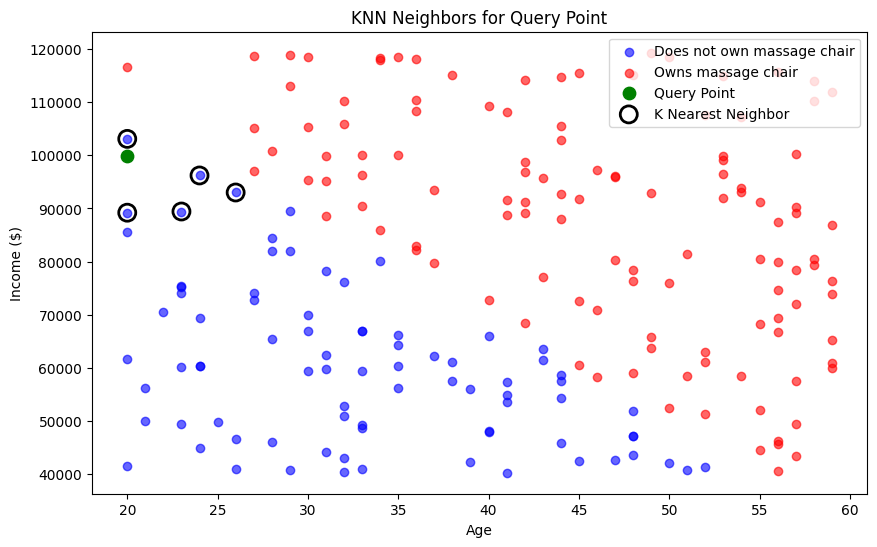

In [12]:
def standardize(x):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    return (x - mean) / std, mean, std

x_train_std, x_train_mean, x_train_stddev = standardize(x_train)
x_query_std = (x_query - x_train_mean) / x_train_stddev
y_query_std, sorted_indices = knn_classify(x_train_std, y_train, x_query_std, k)

print(f'Predicted label for standardized query point: {"Owns Massage Chair" if y_query_std[0] == 1 else "Does Not Own Massage Chair"}')

# Visualize neighbors after standardization
plt.figure(figsize=(10, 6))
plt.scatter(age[~owns_massage_chair], income[~owns_massage_chair], color='blue', label='Does not own massage chair', alpha=0.6)
plt.scatter(age[owns_massage_chair], income[owns_massage_chair], color='red', label='Owns massage chair', alpha=0.6)
plt.scatter(x_query[0][0], x_query[0][1], color='green', label='Query Point', s=80)
for i in range(k):
    idx = sorted_indices[i]
    plt.scatter(x_train[idx][0], x_train[idx][1], facecolors='none', edgecolors='black', s=150, linewidths=2, label=f'K Nearest Neighbor' if i == 0 else "")
plt.title('KNN Neighbors for Query Point')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend(loc='upper right')
plt.show()

Finally, let's look at the decision boundary after standardization. Notice how the boundary now accounts for both Age and Income, reflecting the underlying logic of our synthetic data.

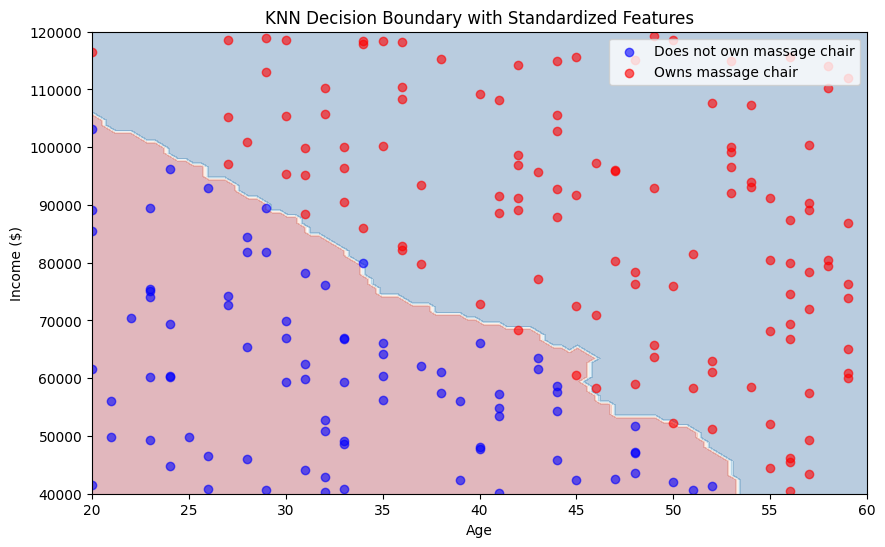

In [ ]:
# Plot decision boundary with scaled features
grid_points_std = (grid_points - x_train_mean) / x_train_stddev
Z, _ = knn_classify(x_train_std, y_train, grid_points_std, k)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(age[~owns_massage_chair], income[~owns_massage_chair], color='blue', label='Does not own massage chair', alpha=0.6)
plt.scatter(age[owns_massage_chair], income[owns_massage_chair], color='red', label='Owns massage chair', alpha=0.6)
plt.title('KNN Decision Boundary with Standardized Features')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend(loc='upper right')
plt.show()

So what did we learn?

1. **k-NN is Distance-Dependent:** Because k-NN relies on distance calculations, the magnitude of feature values matters.
2. **Feature-Range Variation Breaks the Algorithm:** Without feature scaling, variables with large ranges will "drown out" variables with small ranges, even if the latter are just as important.
3. **Standardization Levels the Playing Field:** By centering and scaling the data, we ensure that the algorithm treats all features as equally important contributors to the distance.